# Simulação Computacional: Amostragem da Rede Elétrica

A simulação a seguir modela um cenário prático: a amostragem de um sinal de tensão correspondente à rede elétrica brasileira ($60\,\text{Hz}$), com o objetivo de analisar a conversão de um sinal contínuo para o domínio discreto.

### Metodologia e Parâmetros

A implementação utiliza **Python**, com `numpy` para o processamento numérico e `matplotlib` + `seaborn` para a renderização gráfica em padrão acadêmico.

**Parâmetros do Sinal:**
* Sinal de entrada: Tensão da rede elétrica ($127\,\text{V}_\text{rms}$).
* Amplitude de pico: $A = 127\sqrt{2} \approx 179{,}6\,\text{V}$.
* Frequência do sinal: $f_0 = 60\,\text{Hz}$.
* Frequência de amostragem: $f_s = 480\,\text{Hz}$ (garantindo 8 amostras por ciclo).
* Duração: $3$ ciclos completos ($3T_0 = 50\,\text{ms}$).

O critério de Nyquist é estritamente atendido, pois $f_s = 480\,\text{Hz} > 2f_0 = 120\,\text{Hz}$.

In [2]:
# Importações essenciais
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo com paleta daltônica (colorblind) para originalidade
sns.set_theme(
    context="paper",
    style="ticks",
    palette="colorblind",
    font="serif",
    rc={
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.6,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

In [3]:
# Parâmetros físicos do sinal (Rede Elétrica 60 Hz)
A   = 127.0 * np.sqrt(2) # Tensão de pico [V]
f0  = 60.0               # Frequência do sinal [Hz]
phi = 0.0                # Fase inicial [rad]
fs  = 480.0              # Frequência de amostragem [Hz]
Ts  = 1.0 / fs           # Período de amostragem [s]

# Definição do sinal contínuo via função lambda
x_t = lambda t: A * np.cos(2.0 * np.pi * f0 * t + phi)

# Configuração dos eixos de tempo (3 períodos)
T0       = 1.0 / f0
t_end    = 3.0 * T0
ms_fator = 1000.0 # Conversão para milissegundos na plotagem

# Geração dos vetores
t_continuo = np.linspace(0.0, t_end, 3000)
x_continuo = x_t(t_continuo)

n_amostras = np.arange(0, int(np.floor(t_end * fs)) + 1)
t_discreto = n_amostras * Ts
x_discreto = x_t(t_discreto)

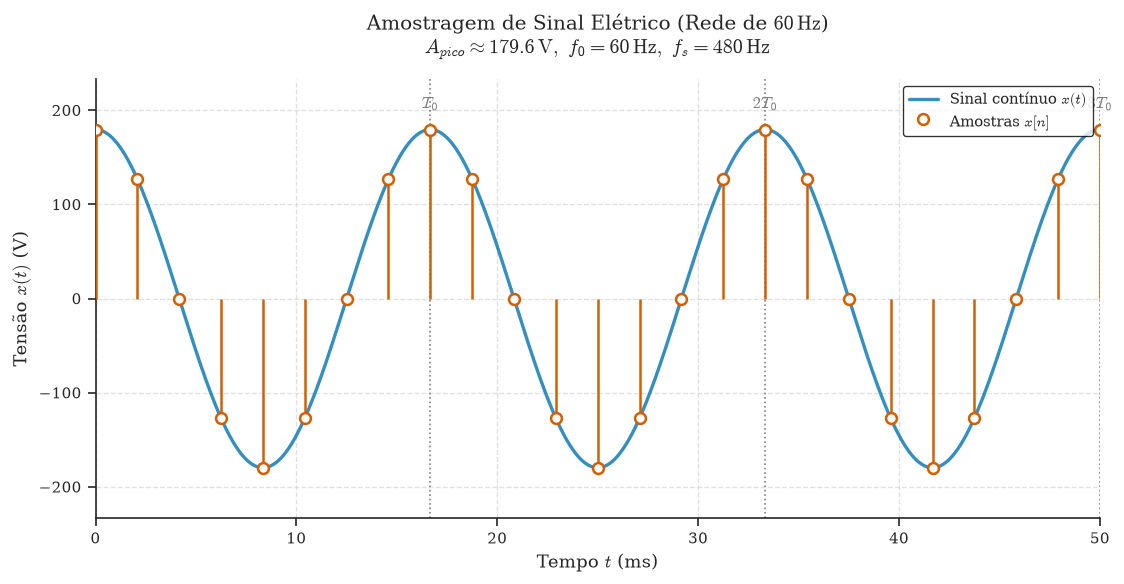

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5))

cores = sns.color_palette("colorblind")
cor_cont = cores[0]  # Azul
cor_disc = cores[3]  # Rosa/Avermelhado

# 1. Plot do Sinal Contínuo
ax.plot(
    t_continuo * ms_fator, x_continuo,
    color=cor_cont, linewidth=2.0, alpha=0.8,
    label=r"Sinal contínuo $x(t)$", zorder=2
)

# 2. Plot do Sinal Discreto (Amostras)
markerline, stemlines, baseline = ax.stem(
    t_discreto * ms_fator, x_discreto,
    linefmt="-", markerfmt="o", basefmt=" ",
    label=r"Amostras $x[n]$",
)
plt.setp(stemlines, color=cor_disc, linewidth=1.5, zorder=3)
plt.setp(markerline, color=cor_disc, markersize=6.5,
         markerfacecolor="white", markeredgewidth=1.5, zorder=4)

# 3. Demarcação dos Ciclos (T0, 2T0, 3T0)
for k in range(1, 4):
    instante = k * T0 * ms_fator
    ax.axvline(instante, color="gray", linewidth=1.0, linestyle=":", zorder=1)
    rotulo = rf"${k}T_0$" if k > 1 else r"$T_0$"
    ax.text(instante, A * 1.1, rotulo, ha="center", va="bottom", fontsize=10, color="gray")

# 4. Ajustes Finais e Textos
ax.set_title(
    r"Amostragem de Sinal Elétrico (Rede de $60\,\mathrm{Hz}$)" "\n"
    rf"$A_{{pico}} \approx {A:.1f}\,\mathrm{{V}},\; f_0 = {f0:.0f}\,\mathrm{{Hz}},\; f_s = {fs:.0f}\,\mathrm{{Hz}}$",
    pad=15
)
ax.set_xlabel(r"Tempo $t$ (ms)")
ax.set_ylabel(r"Tensão $x(t)$ (V)")
ax.set_xlim(0.0, t_end * ms_fator)
ax.set_ylim(-A * 1.3, A * 1.3)

ax.legend(loc="upper right", frameon=True, edgecolor="black")
sns.despine(trim=False)
fig.tight_layout()

# 5. Salvar Imagem (Cria a pasta caso não exista)
import os
os.makedirs("../simulacao", exist_ok=True)
fig.savefig("../simulacao/grafico_rede_eletrica.png")
plt.show()

In [5]:
# Resumo Numérico
print("=== RESULTADOS NUMÉRICOS DA AMOSTRAGEM ===")
print(f"Frequência do Sinal (f0) : {f0} Hz")
print(f"Frequência de Amostragem : {fs} Hz")
print(f"Amostras por ciclo       : {fs/f0:.0f}")
print(f"Total de amostras obtidas: {len(n_amostras)}")
print(f"Intervalo (Ts)           : {Ts*1000:.3f} ms")
print(f"Tensão de Pico           : {np.max(np.abs(x_discreto)):.1f} V")
print("==========================================\n")

# Extração de Dados de Hardware/Software
import platform, psutil
print("=== AMBIENTE DE EXECUÇÃO (REPRODUTIBILIDADE) ===")
print(f"OS     : {platform.system()} {platform.release()}")
print(f"Python : {platform.python_version()}")
print(f"CPU    : {platform.processor()} ({psutil.cpu_count(logical=True)} threads)")
mem = psutil.virtual_memory()
print(f"RAM    : {mem.total / (1024**3):.1f} GB Total / {mem.available / (1024**3):.1f} GB Livre")
print("================================================")

=== RESULTADOS NUMÉRICOS DA AMOSTRAGEM ===
Frequência do Sinal (f0) : 60.0 Hz
Frequência de Amostragem : 480.0 Hz
Amostras por ciclo       : 8
Total de amostras obtidas: 25
Intervalo (Ts)           : 2.083 ms
Tensão de Pico           : 179.6 V

=== AMBIENTE DE EXECUÇÃO (REPRODUTIBILIDADE) ===
OS     : Windows 11
Python : 3.13.7
CPU    : Intel64 Family 6 Model 165 Stepping 3, GenuineIntel (12 threads)
RAM    : 15.9 GB Total / 0.5 GB Livre
